<a href="https://colab.research.google.com/github/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/blob/main/Clustering_%26_Prediction%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import libraries

In [26]:
import pandas as pd
import joblib
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier

### Load the Data

In [2]:
url = "https://raw.githubusercontent.com/Edenshmuel/MIMIC_ICU_Prediction_and_Clustering/refs/heads/main/ICU_data_with_kmeans_clusters.csv"
df = pd.read_csv(url)

### Prepare features and target

In [3]:
X = df.drop(columns=['thirtyday_expire_flag'])
y = df['thirtyday_expire_flag']

### One-hot encode cluster membership

In [4]:
X = pd.get_dummies(X, columns=['cluster_4'])

### Train-test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

### Fit logistic regression model

In [8]:
logreg_clf = LogisticRegression(max_iter=1000, random_state=42)
logreg_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Make predictions & probabilities**

In [9]:
y_pred_logreg = logreg_clf.predict(X_test)
y_proba_logreg = logreg_clf.predict_proba(X_test)[:, 1]

**Evaluate performance**

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("AUC:", roc_auc_score(y_test, y_proba_logreg))
print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.8320526893523601
AUC: 0.8196498919324925
              precision    recall  f1-score   support

         0.0       0.86      0.95      0.90       733
         1.0       0.62      0.36      0.46       178

    accuracy                           0.83       911
   macro avg       0.74      0.65      0.68       911
weighted avg       0.81      0.83      0.81       911



### Create and fit the XGBoost classifier

In [13]:
xgb_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:27:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

**Predictions**

In [14]:
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

**Evaluate performance**

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.845225027442371
AUC: 0.8426429786777442
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91       733
         1.0       0.70      0.37      0.48       178

    accuracy                           0.85       911
   macro avg       0.78      0.66      0.69       911
weighted avg       0.83      0.85      0.83       911



**feature importances**

In [18]:
importances = xgb_clf.feature_importances_
feat_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

**Plot feature importances**

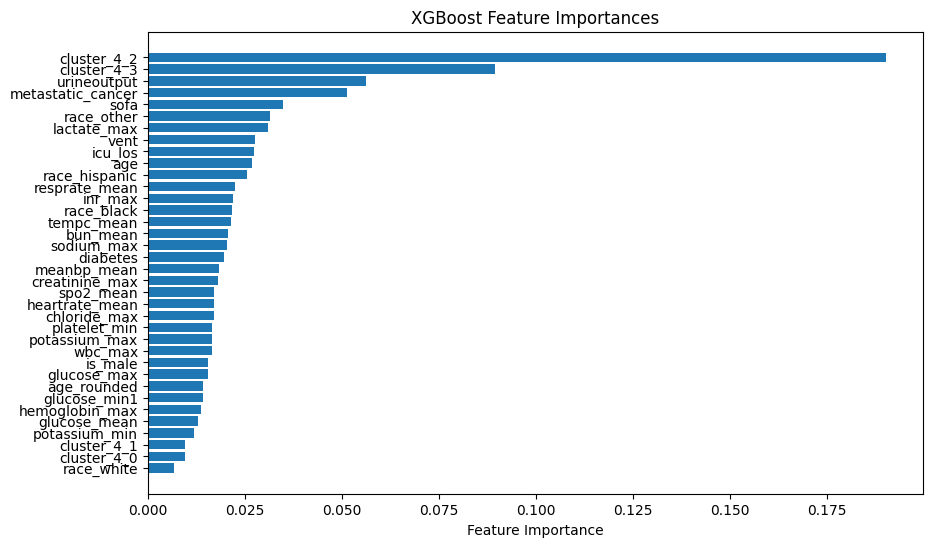

In [19]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.show()

### Create and fit Random Forest model

**Train Random Forest model**

In [21]:
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Make predictions & probabilities**

In [22]:
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

**Evaluate Random Forest performance**

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8430296377607025
AUC: 0.8272529392829223
              precision    recall  f1-score   support

         0.0       0.85      0.98      0.91       733
         1.0       0.79      0.27      0.40       178

    accuracy                           0.84       911
   macro avg       0.82      0.63      0.66       911
weighted avg       0.84      0.84      0.81       911



**Feature importances plot**

In [24]:
importances = rf_clf.feature_importances_
feature_names = X_train.columns

**Plot feature importances**

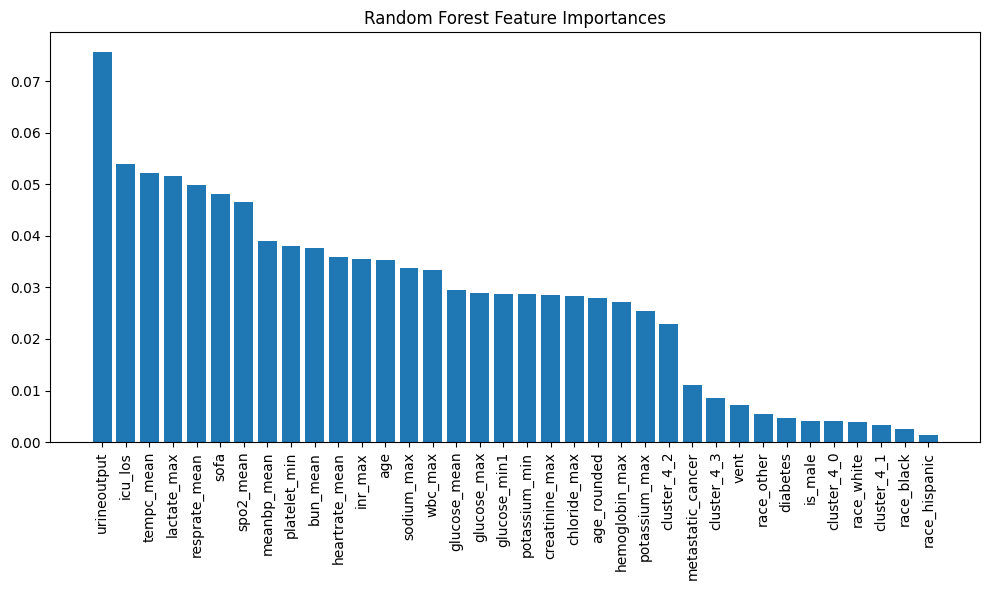

In [27]:
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

### Model comparison summary

| Model                   | Accuracy | AUC    | Feature importance notes                            |
|--------------------------|----------|--------|----------------------------------------------------|
| Logistic Regression      | 0.83     | 0.82   | Relied mainly on clinical and lab features; clusters had minimal effect. |
| XGBoost Classifier       | 0.85     | 0.84   | Clusters (cluster_4_2, cluster_4_3) were top features, indicating strong value of clustering. |
| Random Forest Classifier | 0.84     | 0.83   | Urine output, ICU LOS and temp_mean dominated; clusters were less important. |



### Conclusion
XGBoost achieved slightly better accuracy and AUC while also prominently utilizing the cluster features, suggesting that combining clustering with prediction improves performance. Logistic Regression and Random Forest performed comparably, but relied more on traditional features.


### Does clustering help improve prediction?

Based on our results, adding the cluster features did slightly improve model performance.

- In the XGBoost model, the clusters (cluster_4_2 and cluster_4_3) were among the most important predictors, and the AUC increased to 0.84, higher than Logistic Regression (0.82).

- The Random Forest model showed more modest reliance on the clusters, with similar overall metrics.

This suggests that incorporating clustering into the prediction pipeline can enhance the model by capturing latent patient phenotypes that are not directly reflected in individual clinical variables. Thus, clustering did help improve prediction, especially in more complex models like XGBoost.